# Step 1 : Load required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2 : Load the Cleaned Dataset

In [3]:
customers = pd.read_csv("customers_cleaned.csv")
orders = pd.read_csv("orders_cleaned.csv")
restaurants = pd.read_csv("restaurants_cleaned.csv")
delivery = pd.read_csv("delivery_partners_cleaned.csv")

# Step 3 : Dataset Overview

In [4]:
print("Customers Shape :", customers.shape)
print("Orders Shape :", orders.shape)
print("Restaurants Shape :", restaurants.shape)
print("Delivery Shape :", delivery.shape)

Customers Shape : (22000, 8)
Orders Shape : (100000, 15)
Restaurants Shape : (550, 7)
Delivery Shape : (1100, 9)


In [5]:
customers.head()

,Customer_ID,Gender,Age_Group,City,Customer_Type,Total_Orders,Average_Spend,Preferred_Cuisine
0,C00001,Female,36-50,Urban,New,1,375,Italian
1,C00002,Female,36-50,Urban,New,2,320,Italian
2,C00003,Female,36-50,Metropolitian,New,2,450,North Indian
3,C00004,Female,26-35,Urban,New,2,140,South Indian
4,C00005,Male,18-25,Urban,New,1,282,North Indian


In [6]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Restaurant_ID,Region,Delivery_Partner_ID,Order_Value,Delivery_Fee,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Delivery_Time_Minutes,Order_Rating,Festival_Flag
0,O809577,2025-04-12,C01162,R282,Metropolitian,D0496,423,30,0,453,Card,Delivered,40,4,False
1,O613973,2023-01-14,C05894,R181,Semi-Urban,D0624,416,30,0,446,Wallet,Delivered,32,4,False
2,O133055,2024-05-29,C02487,R303,Semi-Urban,D0044,465,50,0,515,UPI,Returned,34,4,False
3,O721755,2025-09-09,C01639,R409,Semi-Urban,D0988,345,30,75,300,Cash,Delivered,36,3,False
4,O566596,2024-11-01,C05141,R358,Semi-Urban,D1087,611,30,30,611,Card,Delivered,31,3,True


In [7]:
restaurants.head()

,Restaurant_ID,City,Avg_Preparation_Time_Minutes,Avg_Rating,Order_Capacity_Per_Day,Restaurant_Name,Cuisine_Type
0,R001,Metropolitian,27,4.64,114,Restaurant_900,Fast Food
1,R002,Semi-Urban,40,4.10,1,Restaurant_1003,Italian
2,R003,Urban,24,4.71,30,Restaurant_671,Indian
3,R004,Urban,23,4.71,32,Restaurant_620,Fast Food
4,R005,Urban,25,4.72,28,Restaurant_926,Fast Food


In [8]:
delivery.head()

,Delivery_Partner_ID,Partner_Name,Vehicle_Type,Avg_Delivery_Speed_KMPH,Successful_Deliveries,Delayed_Deliveries,Avg_Customer_Rating,Region,Delivery_Efficiency_Score
0,D0001,Arjun Sharma,Scooter,23.310805,42,5,4.634091,Metropolitian,0.810
1,D0002,Vikram Gupta,Bike,21.378411,25,4,4.644444,Metropolitian,0.784
2,D0003,Vikram Chopra,Bike,16.008422,8,1,4.637500,Urban,0.754
3,D0004,Kiran Sharma,Bike,15.686597,9,0,4.650000,Urban,0.797
4,D0005,Arjun Sharma,Scooter,24.361525,5,0,4.460000,Metropolitian,0.850


# Step 4 : Rename Columns

In [9]:
# Rename Columns
# Avoid duplicate column names after merging

customers.rename(
    columns={"City": "Customer_City"},
    inplace=True
)

restaurants.rename(
    columns={"City": "Restaurant_City"},
    inplace=True
)

delivery.rename(
    columns={"Region": "Delivery_Region"},
    inplace=True
)

# Step 5 : Referential Integrity Check

In [10]:
print(orders["Customer_ID"].isin(customers["Customer_ID"]).all())

print(orders["Restaurant_ID"].isin(restaurants["Restaurant_ID"]).all())

print(orders["Delivery_Partner_ID"].isin(delivery["Delivery_Partner_ID"]).all())

True
True
True


# Step 6 : Master Dataset Creation

In [11]:
foodtech = (
    orders
    .merge(
        customers,
        on="Customer_ID",
        how="left"
    )
    .merge(
        restaurants,
        on="Restaurant_ID",
        how="left"
    )
    .merge(
        delivery,
        on="Delivery_Partner_ID",
        how="left"
    )
)

# Step 7 : Verify Master Dataset

In [12]:
foodtech.shape

(100000, 36)

In [13]:
foodtech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Order_ID                      100000 non-null  object 
 1   Order_Date                    100000 non-null  object 
 2   Customer_ID                   100000 non-null  object 
 3   Restaurant_ID                 100000 non-null  object 
 4   Region                        100000 non-null  object 
 5   Delivery_Partner_ID           100000 non-null  object 
 6   Order_Value                   100000 non-null  int64  
 7   Delivery_Fee                  100000 non-null  int64  
 8   Discount_Applied              100000 non-null  int64  
 9   Final_Amount                  100000 non-null  int64  
 10  Payment_Mode                  100000 non-null  object 
 11  Order_Status                  100000 non-null  object 
 12  Delivery_Time_Minutes         100000 non-null

In [14]:
foodtech.isnull().sum()

Order_ID                        0
Order_Date                      0
Customer_ID                     0
Restaurant_ID                   0
Region                          0
Delivery_Partner_ID             0
Order_Value                     0
Delivery_Fee                    0
Discount_Applied                0
Final_Amount                    0
Payment_Mode                    0
Order_Status                    0
Delivery_Time_Minutes           0
Order_Rating                    0
Festival_Flag                   0
Gender                          0
Age_Group                       0
Customer_City                   0
Customer_Type                   0
Total_Orders                    0
Average_Spend                   0
Preferred_Cuisine               0
Restaurant_City                 0
Avg_Preparation_Time_Minutes    0
Avg_Rating                      0
Order_Capacity_Per_Day          0
Restaurant_Name                 0
Cuisine_Type                    0
Partner_Name                    0
Vehicle_Type  

In [15]:
foodtech.duplicated().sum()

np.int64(0)

# Step 8 : Convert Date Column

In [16]:
foodtech["Order_Date"] = pd.to_datetime(
    foodtech["Order_Date"]
)

# Step 9 : Feature Engineering

In [17]:
# Feature 1 : Order_Year

foodtech["Order_Year"] = foodtech["Order_Date"].dt.year

# Validate
foodtech["Order_Year"].value_counts().sort_index()

Order_Year
2023    33320
2024    33312
2025    33368
Name: count, dtype: int64

In [18]:
# Feature 2 : Order_Month

foodtech["Order_Month"] = foodtech["Order_Date"].dt.month

# Validate
foodtech["Order_Month"].value_counts().sort_index()

Order_Month
1     7712
2     7678
3     8632
4     7836
5     7714
6     7706
7     8471
8     8416
9     7955
10    9614
11    9217
12    9049
Name: count, dtype: int64

In [19]:
# Feature 3 : Month_Name

foodtech["Month_Name"] = foodtech["Order_Date"].dt.month_name()

# Validate
foodtech["Month_Name"].value_counts().sort_values()

Month_Name
February     7678
June         7706
January      7712
May          7714
April        7836
September    7955
August       8416
July         8471
March        8632
December     9049
November     9217
October      9614
Name: count, dtype: int64

In [20]:
foodtech.groupby("Order_Month")["Month_Name"].value_counts()

Order_Month  Month_Name
1            January       7712
2            February      7678
3            March         8632
4            April         7836
5            May           7714
6            June          7706
7            July          8471
8            August        8416
9            September     7955
10           October       9614
11           November      9217
12           December      9049
Name: count, dtype: int64

In [21]:
# Feature 4 : Order_Quarter

foodtech["Order_Quarter"] = foodtech["Order_Date"].dt.quarter

# Validate
foodtech["Order_Quarter"].value_counts().sort_index()

Order_Quarter
1    24022
2    23256
3    24842
4    27880
Name: count, dtype: int64

In [22]:
# Feature 5 : Day_Name

foodtech["Day_Name"] = foodtech["Order_Date"].dt.day_name()

# Validate
foodtech["Day_Name"].value_counts().sort_index()

Day_Name
Friday       14151
Monday       14337
Saturday     14336
Sunday       14315
Thursday     14183
Tuesday      14333
Wednesday    14345
Name: count, dtype: int64

In [23]:
# For order wise, we have to convert Day_Name to an ordered category

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

foodtech["Day_Name"] = pd.Categorical(
    foodtech["Day_Name"],
    categories=day_order,
    ordered=True
)

foodtech["Day_Name"].value_counts().sort_index()

Day_Name
Monday       14337
Tuesday      14333
Wednesday    14345
Thursday     14183
Friday       14151
Saturday     14336
Sunday       14315
Name: count, dtype: int64

In [24]:
# Feature 6 - Is_Weekend
# Purpose : This feature will help answer questions like: Are weekend orders higher than weekday orders?,
# Do ratings change between weekdays and weekends? etc

foodtech["Is_Weekend"] = np.where(
    foodtech["Day_Name"].isin(["Saturday","Sunday"]),
    "Weekend",
    "Weekday"
)

# Validation
foodtech["Is_Weekend"].value_counts()

Is_Weekend
Weekday    71349
Weekend    28651
Name: count, dtype: int64

In [25]:
# Feature 7: Discount_Percentage
# Purpose: Standardizes discounts across different order values.
#
# Example:
# Order 1: Value = ₹100, Discount = ₹10 → 10%
# Order 2: Value = ₹1000, Discount = ₹10 → 1%
#
# Although both orders receive the same ₹10 discount,
# the discount impact is different. This feature helps
# analyze discount strategies more effectively.

foodtech["Discount_Percentage"] = (
    foodtech["Discount_Applied"] / foodtech["Order_Value"]
) * 100

foodtech["Discount_Percentage"] = foodtech["Discount_Percentage"].round(2)

# Validation
foodtech[["Order_Value", "Discount_Applied", "Discount_Percentage"]].head(10)

,Order_Value,Discount_Applied,Discount_Percentage
0,423,0,0.00
1,416,0,0.00
2,465,0,0.00
3,345,75,21.74
4,611,30,4.91
5,750,0,0.00
6,551,100,18.15
7,253,20,7.91
8,331,0,0.00
9,554,50,9.03


In [26]:
# Feature 8 : Delivery_Time_Category
# Purpose : Categorizes delivery time into Fast, Moderate and Slow for delivery performance analysis

foodtech["Delivery_Time_Category"] = np.where(
    foodtech["Delivery_Time_Minutes"] <= 30, "Fast",
    np.where(
        foodtech["Delivery_Time_Minutes"] <=45, "Moderate",
        "Slow")
)

# Validation
print(foodtech[["Delivery_Time_Minutes","Delivery_Time_Category"]].head(10))
print()
print(foodtech["Delivery_Time_Category"].value_counts())

   Delivery_Time_Minutes Delivery_Time_Category
0                     40               Moderate
1                     32               Moderate
2                     34               Moderate
3                     36               Moderate
4                     31               Moderate
5                     29                   Fast
6                     36               Moderate
7                     32               Moderate
8                     40               Moderate
9                     43               Moderate

Delivery_Time_Category
Moderate    81761
Fast        15997
Slow         2242
Name: count, dtype: int64


In [27]:
# Feature 9: Order_Value_Category
# Purpose: Categorizes orders into Low, Medium, and High value segments for spending analysis.
# This feature will help answer questions like: 
# Which order value segment generates the most revenue?
# Which segment places the most orders?
# Which segment receives the highest ratings? etc

In [28]:
foodtech["Order_Value"].describe()

# So the data is centered around ₹542 (Median), with most orders falling between ₹429 (Q1 - 25%) and ₹656 (Q3 - 75%).

count    100000.000000
mean        545.677920
std         167.167972
min         200.000000
25%         429.000000
50%         542.000000
75%         656.000000
max        1200.000000
Name: Order_Value, dtype: float64

In [29]:
# Categorizing the ranges

foodtech["Order_Value_Category"] = np.where(
    foodtech["Order_Value"] <= 400,
    "Low Value",
    np.where(
        foodtech["Order_Value"] <= 700,
        "Medium Value",
        "High Value")
)

# Validation
foodtech["Order_Value_Category"].value_counts()

Order_Value_Category
Medium Value    62520
Low Value       19834
High Value      17646
Name: count, dtype: int64

# Step 10 : Verify Engineered Dataset

In [30]:
foodtech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 45 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Order_ID                      100000 non-null  object        
 1   Order_Date                    100000 non-null  datetime64[ns]
 2   Customer_ID                   100000 non-null  object        
 3   Restaurant_ID                 100000 non-null  object        
 4   Region                        100000 non-null  object        
 5   Delivery_Partner_ID           100000 non-null  object        
 6   Order_Value                   100000 non-null  int64         
 7   Delivery_Fee                  100000 non-null  int64         
 8   Discount_Applied              100000 non-null  int64         
 9   Final_Amount                  100000 non-null  int64         
 10  Payment_Mode                  100000 non-null  object        
 11  Order_Status  

In [31]:
foodtech.head()

,Order_ID,Order_Date,Customer_ID,Restaurant_ID,Region,Delivery_Partner_ID,Order_Value,Delivery_Fee,Discount_Applied,Final_Amount,...,Delivery_Efficiency_Score,Order_Year,Order_Month,Month_Name,Order_Quarter,Day_Name,Is_Weekend,Discount_Percentage,Delivery_Time_Category,Order_Value_Category
0,O809577,2025-04-12,C01162,R282,Metropolitian,D0496,423,30,0,453,...,0.779,2025,4,April,2,Saturday,Weekend,0.00,Moderate,Medium Value
1,O613973,2023-01-14,C05894,R181,Semi-Urban,D0624,416,30,0,446,...,0.302,2023,1,January,1,Saturday,Weekend,0.00,Moderate,Medium Value
2,O133055,2024-05-29,C02487,R303,Semi-Urban,D0044,465,50,0,515,...,0.353,2024,5,May,2,Wednesday,Weekday,0.00,Moderate,Medium Value
3,O721755,2025-09-09,C01639,R409,Semi-Urban,D0988,345,30,75,300,...,0.493,2025,9,September,3,Tuesday,Weekday,21.74,Moderate,Low Value
4,O566596,2024-11-01,C05141,R358,Semi-Urban,D1087,611,30,30,611,...,0.422,2024,11,November,4,Friday,Weekday,4.91,Moderate,Medium Value


# Step 11 : Export Final Dataset

In [32]:
foodtech.to_csv("FoodTech_Analysis_Dataset.csv", index=False)

In [33]:
# Export in xlsx format

foodtech.to_excel("FoodTech_Analysis_Dataset.xlsx",index=False)

# Step 12 : Verify Export

In [35]:
foodtech_analysis = pd.read_csv("FoodTech_Analysis_Dataset.csv")

foodtech_analysis.shape

(100000, 45)

# Step 13 : Connection with SQL 

In [34]:
# To connect python to MySQL, I have installed required python packages

!pip install sqlalchemy pymysql

In [35]:
# Import the libraries

import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [36]:
# Load the final Analysis Dataset

foodtech = pd.read_csv("FoodTech_Analysis_Dataset.csv")
foodtech.head()

,Order_ID,Order_Date,Customer_ID,Restaurant_ID,Region,Delivery_Partner_ID,Order_Value,Delivery_Fee,Discount_Applied,Final_Amount,...,Delivery_Efficiency_Score,Order_Year,Order_Month,Month_Name,Order_Quarter,Day_Name,Is_Weekend,Discount_Percentage,Delivery_Time_Category,Order_Value_Category
0,O809577,2025-04-12,C01162,R282,Metropolitian,D0496,423,30,0,453,...,0.779,2025,4,April,2,Saturday,Weekend,0.00,Moderate,Medium Value
1,O613973,2023-01-14,C05894,R181,Semi-Urban,D0624,416,30,0,446,...,0.302,2023,1,January,1,Saturday,Weekend,0.00,Moderate,Medium Value
2,O133055,2024-05-29,C02487,R303,Semi-Urban,D0044,465,50,0,515,...,0.353,2024,5,May,2,Wednesday,Weekday,0.00,Moderate,Medium Value
3,O721755,2025-09-09,C01639,R409,Semi-Urban,D0988,345,30,75,300,...,0.493,2025,9,September,3,Tuesday,Weekday,21.74,Moderate,Low Value
4,O566596,2024-11-01,C05141,R358,Semi-Urban,D1087,611,30,30,611,...,0.422,2024,11,November,4,Friday,Weekday,4.91,Moderate,Medium Value


In [37]:
# Create Database Connection

username = "root"
password = quote_plus("Srik@nth18_06_03")  
host = "localhost"
port = 3306
database = "FoodTech_Analytics"

connection_string = (
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(connection_string)

In [38]:
# Test the connection

with engine.connect() as conn:
    print("SQLAlchemy Connected Successfully!")

SQLAlchemy Connected Successfully!


In [39]:
# Upload Dataset to MySQL

foodtech.to_sql(
    name="foodtech_analysis",
    con=engine,
    if_exists="replace",
    index=False
)

print("Dataset uploaded successfully!")

Dataset uploaded successfully!


In [40]:
# Verify the upload

query = "SELECT COUNT(*) AS Total_Rows FROM foodtech_analysis"
pd.read_sql(query, engine)

,Total_Rows
0,100000


In [41]:
# Verify the sample record

query = """
SELECT *
FROM foodtech_analysis
LIMIT 10;
"""

pd.read_sql(query, engine)

,Order_ID,Order_Date,Customer_ID,Restaurant_ID,Region,Delivery_Partner_ID,Order_Value,Delivery_Fee,Discount_Applied,Final_Amount,...,Delivery_Efficiency_Score,Order_Year,Order_Month,Month_Name,Order_Quarter,Day_Name,Is_Weekend,Discount_Percentage,Delivery_Time_Category,Order_Value_Category
0,O809577,2025-04-12,C01162,R282,Metropolitian,D0496,423,30,0,453,...,0.779,2025,4,April,2,Saturday,Weekend,0.00,Moderate,Medium Value
1,O613973,2023-01-14,C05894,R181,Semi-Urban,D0624,416,30,0,446,...,0.302,2023,1,January,1,Saturday,Weekend,0.00,Moderate,Medium Value
2,O133055,2024-05-29,C02487,R303,Semi-Urban,D0044,465,50,0,515,...,0.353,2024,5,May,2,Wednesday,Weekday,0.00,Moderate,Medium Value
3,O721755,2025-09-09,C01639,R409,Semi-Urban,D0988,345,30,75,300,...,0.493,2025,9,September,3,Tuesday,Weekday,21.74,Moderate,Low Value
4,O566596,2024-11-01,C05141,R358,Semi-Urban,D1087,611,30,30,611,...,0.422,2024,11,November,4,Friday,Weekday,4.91,Moderate,Medium Value
5,O547279,2023-12-09,C10075,R013,Urban,D0435,750,35,0,785,...,0.831,2023,12,December,4,Saturday,Weekend,0.00,Fast,High Value
6,O171038,2025-04-12,C11124,R148,Metropolitian,D0729,551,40,100,491,...,0.840,2025,4,April,2,Saturday,Weekend,18.15,Moderate,Medium Value
7,O202306,2025-12-31,C05458,R189,Semi-Urban,D1010,253,35,20,268,...,0.464,2025,12,December,4,Wednesday,Weekday,7.91,Moderate,Low Value
8,O466350,2024-11-08,C01744,R303,Semi-Urban,D1087,331,30,0,361,...,0.422,2024,11,November,4,Friday,Weekday,0.00,Moderate,Low Value
9,O523906,2025-10-06,C20904,R177,Metropolitian,D0275,554,30,50,534,...,0.738,2025,10,October,4,Monday,Weekday,9.03,Moderate,Medium Value


# Step 14 : Exploratory Data Analysis

### Objective

The purpose of this analysis is to understand customer behavior, delivery performance, regional demand, and restaurant trends using the integrated FoodTech master dataset.

The insights generated from this section will support the business objectives related to market expansion, logistics optimization, customer retention, and profitability.

In [42]:
# Business Question 1 : Which regions generate the highest revenue?

region_revenue = (
    foodtech
    .groupby("Region")["Final_Amount"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

Region
Urban            18751416
Semi-Urban       18656076
Metropolitian    18587740
Name: Final_Amount, dtype: int64

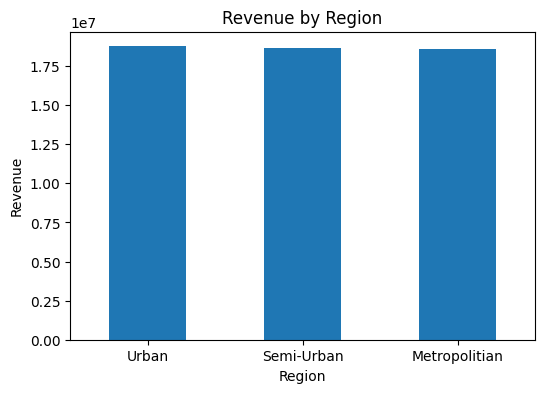

In [48]:
import matplotlib.pyplot as plt

region_revenue.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

### Interpretation

- Revenue is nearly identical across all three regions (within ~1% of each other — Urban ₹1.88 Cr, Semi-Urban ₹1.87 Cr, Metropolitan ₹1.86 Cr), showing no single region dominates demand.
- This balance suggests market saturation is even, so expansion or logistics investment should be spread across all regions rather than concentrated in one.
- Urban leads only marginally, so any resource allocation decision should be based on other factors (delivery cost, growth potential) rather than current revenue alone.

In [44]:
# Business Question 2 : Which customer segment contributes the highest revenue?

customer_revenue = (
    foodtech
    .groupby("Customer_Type")["Final_Amount"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue

Customer_Type
New          30260711
Returning    19547115
Loyal         6187406
Name: Final_Amount, dtype: int64

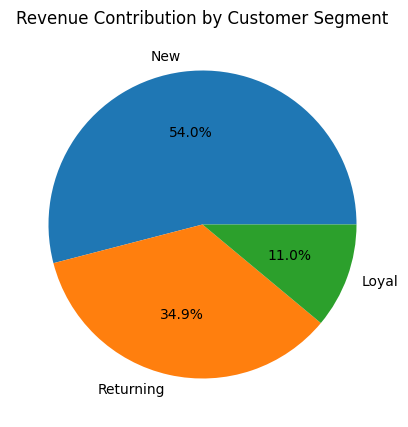

In [50]:
customer_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.ylabel("")
plt.title("Revenue Contribution by Customer Segment")

plt.show()

### Interpretation

- New customers drive over half of total revenue (54%, ₹3.03 Cr), showing strong customer acquisition, but heavy reliance on first-time buyers can be volatile if acquisition spend slows.
- Returning customers contribute a solid 34.9% (₹1.95 Cr), indicating decent repeat-purchase behavior — the natural next step is converting more of this group into Loyal.
- Loyal customers generate only 11% of revenue (₹61.9 lakh) despite presumably being the platform's longest-engaged users — this is the weakest link, and a structured loyalty/retention program could unlock meaningful upside here.

In [46]:
# Business Question 3 : Which cuisines generate the highest revenue?

cuisine_revenue = (
    foodtech
    .groupby("Cuisine_Type")["Final_Amount"]
    .sum()
    .sort_values(ascending=True)
)

cuisine_revenue

Cuisine_Type
Fast Food    11843171
Indian       12734584
Chinese      15075092
Italian      16342385
Name: Final_Amount, dtype: int64

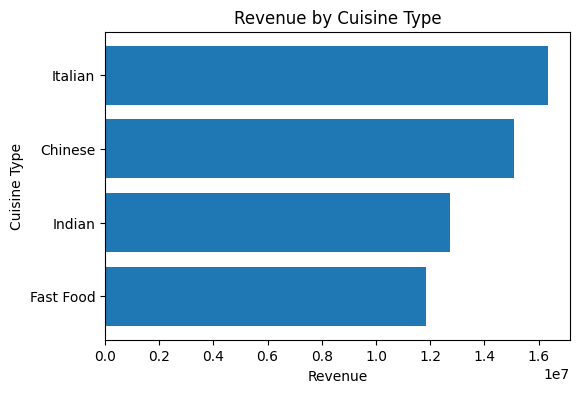

In [47]:
plt.figure(figsize=(6,4))

plt.barh(
    cuisine_revenue.index,
    cuisine_revenue.values
)

plt.title("Revenue by Cuisine Type")
plt.xlabel("Revenue")
plt.ylabel("Cuisine Type")

plt.show()

### Interpretation

- Italian is the top revenue generator (₹1.63 Cr), roughly 38% higher than Fast Food, making it the platform's strongest cuisine category.
- Chinese follows closely (₹1.51 Cr), and together Italian + Chinese account for over half of cuisine revenue — these two categories are worth prioritizing for restaurant partnerships and promotions.
- Indian and Fast Food trail behind (₹1.27 Cr and ₹1.18 Cr), suggesting room to grow through targeted promotions, menu expansion, or discovery placement rather than assuming lower inherent demand.

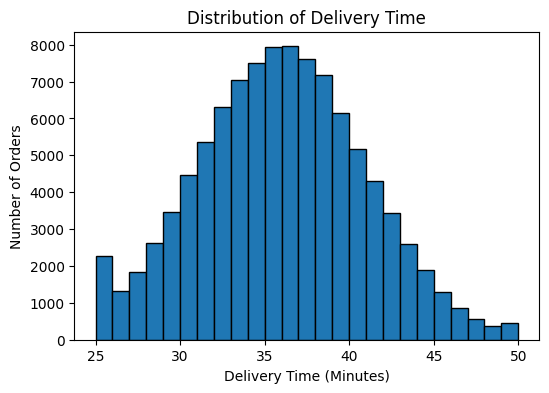

In [51]:
# Business Question 4 : How are delivery times distributed?

plt.figure(figsize=(6,4))

plt.hist(
    foodtech["Delivery_Time_Minutes"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.show()

### Interpretation

- Delivery times follow a roughly normal (bell-shaped) distribution centered around 35–37 minutes, meaning most orders are delivered within a predictable, consistent window rather than being erratic.
- Very few orders fall at the extremes — under 27 minutes or over 45 minutes — indicating both very fast and very slow deliveries are rare, which is a positive sign for operational consistency.
- Since the peak sits at ~36 minutes rather than closer to 25–30, there may be room to tighten the average delivery time through route optimization or fleet mix (e.g., more scooters/bikes), which would shift the whole distribution left and improve customer satisfaction.

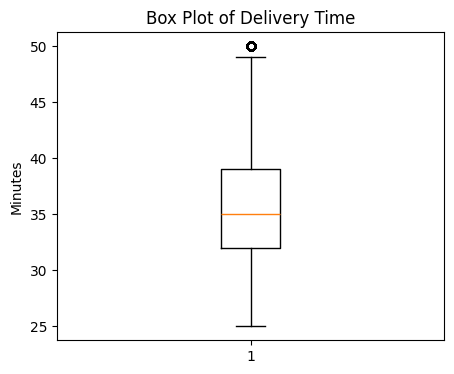

In [53]:
# Business Question 5 : Are there outliers in delivery time?

plt.figure(figsize=(5,4))
plt.boxplot(foodtech["Delivery_Time_Minutes"])
plt.title("Box Plot of Delivery Time")
plt.ylabel("Minutes")
plt.show()

### Interpretation

- The median delivery time is 35 minutes, with the middle 50% of orders (IQR) falling between roughly 32–39 minutes — a tight, consistent range for typical deliveries.
- There's essentially only one mild outlier near 50 minutes, and the whiskers extend cleanly from ~25 to ~49 minutes, meaning there are no extreme or abnormal delays skewing operations.
- The near-symmetric box (median close to the center of the IQR) confirms the distribution isn't skewed — delivery performance is stable and doesn't need urgent outlier-driven intervention, though the upper whisker/outlier near 50 min could still be worth spot-checking for root cause (traffic, distance, restaurant prep delays).

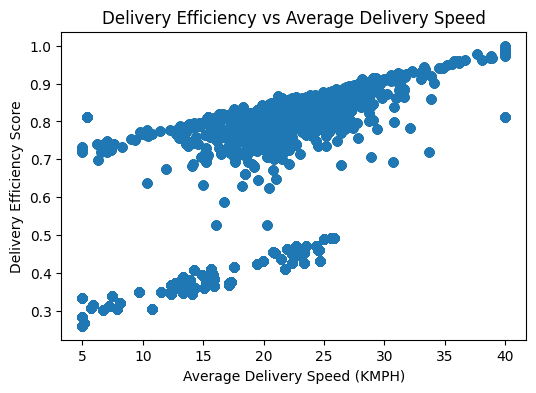

In [54]:
# Business Question 6 : Is there a relationship between Delivery Efficiency Score and Average Delivery Speed?

plt.figure(figsize=(6,4))

plt.scatter(
    foodtech["Avg_Delivery_Speed_KMPH"],
    foodtech["Delivery_Efficiency_Score"],
    alpha=0.5
)

plt.title("Delivery Efficiency vs Average Delivery Speed")
plt.xlabel("Average Delivery Speed (KMPH)")
plt.ylabel("Delivery Efficiency Score")
plt.show()

### Interpretation

- A positive relationship is observed between average delivery speed and delivery efficiency score, indicating that faster delivery partners generally achieve higher operational efficiency.
- The scatter plot reveals two distinct clusters of observations rather than a single continuous trend, suggesting that additional factors such as vehicle type, delivery region, or partner characteristics may influence delivery efficiency.
- Improving the performance of the lower-efficiency group through route optimization, better vehicle allocation, or operational training could significantly enhance overall delivery efficiency without relying solely on increasing delivery speed.

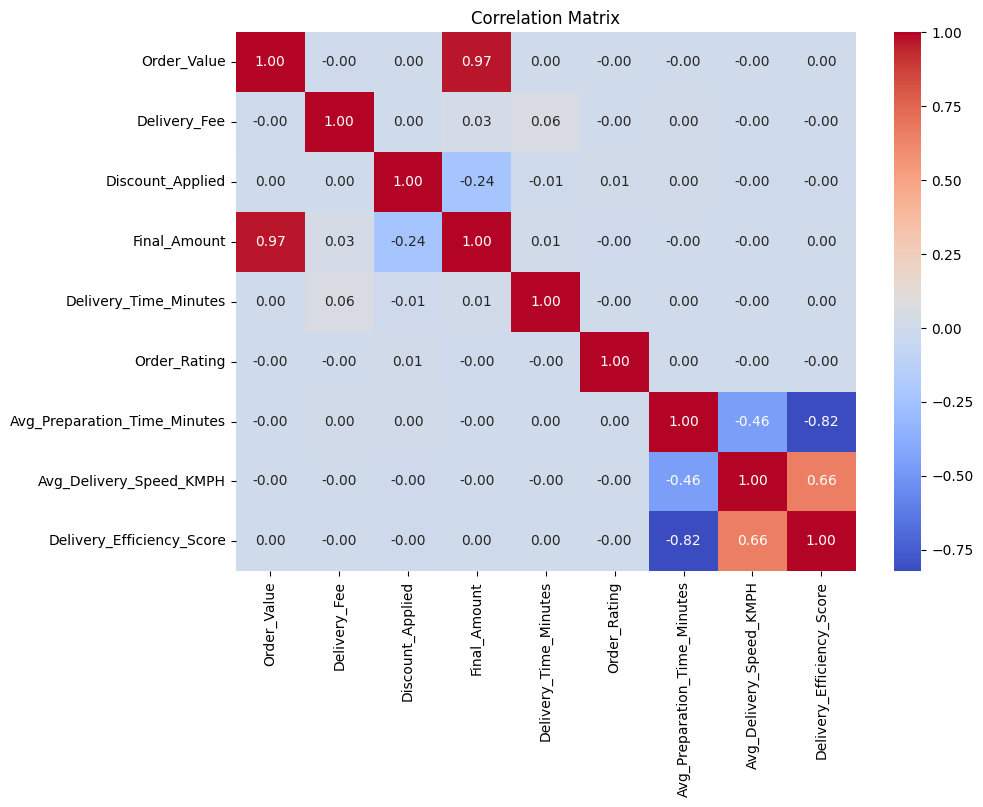

In [55]:
# Business Question 7 : Which numerical variables are strongly correlated?

import seaborn as sns

numerical_columns = [
    "Order_Value",
    "Delivery_Fee",
    "Discount_Applied",
    "Final_Amount",
    "Delivery_Time_Minutes",
    "Order_Rating",
    "Avg_Preparation_Time_Minutes",
    "Avg_Delivery_Speed_KMPH",
    "Delivery_Efficiency_Score"
]

corr = foodtech[numerical_columns].corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Interpretation

- Order_Value and Final_Amount are almost perfectly correlated (0.97), which is expected since Final_Amount is largely derived from Order_Value — Discount_Applied has only a mild negative effect (-0.24) on it.
- Delivery_Efficiency_Score is strongly driven by Avg_Preparation_Time_Minutes (-0.82, strong negative) and Avg_Delivery_Speed_KMPH (0.66, strong positive) — meaning efficiency is much more a function of kitchen prep time and delivery speed than any order/payment variable.
- Most other variables (Delivery_Fee, Delivery_Time_Minutes, Order_Rating) show near-zero correlation with everything else, so they behave largely independently — this also confirms Order_Rating isn't being influenced by delivery speed or time in this dataset, worth noting since it means customer satisfaction may hinge on factors outside this data (food quality, app experience, etc.).

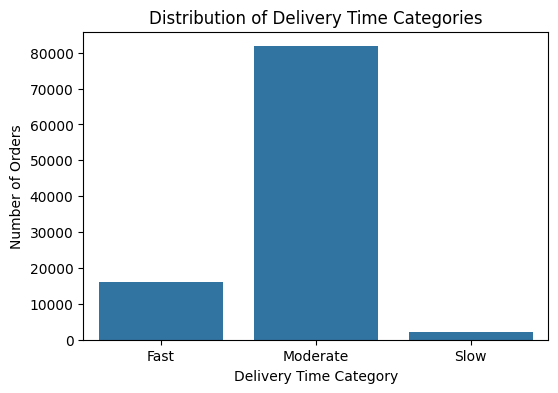

In [60]:
# Business Question 8 : How are orders distributed across Delivery Time Categories?

plt.figure(figsize=(6,4))

sns.countplot(
    data=foodtech,
    x="Delivery_Time_Category",
    order=["Fast","Moderate","Slow"]
)

plt.title("Distribution of Delivery Time Categories")
plt.xlabel("Delivery Time Category")
plt.ylabel("Number of Orders")
plt.show()

### Interpretation

- The vast majority of orders (~82,000, roughly 82%) fall into the "Moderate" delivery time category, meaning most deliveries are neither exceptionally fast nor slow — operations are consistent but not optimized for speed.
- Only ~16,000 orders (16%) qualify as "Fast," suggesting significant room to shift more deliveries from Moderate into Fast through route optimization, better vehicle allocation, or reduced kitchen prep time.
- "Slow" deliveries are minimal (~2,000, about 2%), confirming severe delays are rare and not a major operational risk — the real opportunity lies in tightening the Moderate bucket rather than fixing outliers.

# Statistical Analysis

## Objective

The purpose of this section is to apply statistical techniques to validate business assumptions, measure relationships between variables, and support data-driven decision-making for the Food Delivery platform.

In [61]:
# Total number of orders

total_orders = len(foodtech)

# Orders that are Slow and Rating < 4

joint_orders = foodtech[
    (foodtech["Delivery_Time_Category"] == "Slow") &
    (foodtech["Order_Rating"] < 4)
]

joint_probability = len(joint_orders) / total_orders

print("Total Orders :", total_orders)
print("Orders satisfying both conditions :", len(joint_orders))
print(f"Joint Probability = {joint_probability:.4f}")
print(f"Joint Probability (%) = {joint_probability*100:.2f}%")

Total Orders : 100000
Orders satisfying both conditions : 527
Joint Probability = 0.0053
Joint Probability (%) = 0.53%


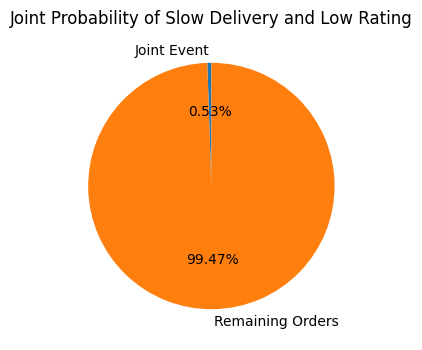

In [63]:
import matplotlib.pyplot as plt

labels = ["Joint Event", "Remaining Orders"]

sizes = [
    len(joint_orders),
    total_orders - len(joint_orders)
]

plt.figure(figsize=(4,4))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Joint Probability of Slow Delivery and Low Rating")
plt.show()

### Interpretation

- Only 0.53% of all orders (527 out of 100,000) experience both a slow delivery and a low rating — this is a very rare joint event, confirming that delivery delays alone aren't the dominant driver of poor customer satisfaction.
- Since "Slow" deliveries make up ~2% of orders but the joint event is only 0.53%, most slow deliveries don't actually result in a low rating — meaning customers are often tolerant of occasional delays, and other factors (food quality, order accuracy, app experience) likely matter more to satisfaction.
- Given how rare this combined risk is, it doesn't require urgent operational intervention on its own — but tracking it over time is still worthwhile as an early-warning indicator if it starts trending upward alongside delivery volume growth.

### Business Recommendation

- Continue monitoring slow deliveries as a key operational metric while also focusing on improving food quality, order accuracy, and customer service, as these factors appear to have a stronger influence on customer satisfaction.
- Track this joint probability periodically to identify any upward trend that may indicate emerging logistics or service quality issues.

In [64]:
# Orders delivered in the Fast category

fast_orders = foodtech[
    foodtech["Delivery_Time_Category"] == "Fast"
]

# Fast deliveries with rating >=4

fast_high_rating = fast_orders[
    fast_orders["Order_Rating"] >= 4
]

conditional_probability = (
    len(fast_high_rating)
    / len(fast_orders)
)

print("Fast Deliveries :", len(fast_orders))
print("Fast Deliveries with Rating >=4 :", len(fast_high_rating))
print(f"Conditional Probability = {conditional_probability:.4f}")
print(f"Conditional Probability (%) = {conditional_probability*100:.2f}%")

Fast Deliveries : 15997
Fast Deliveries with Rating >=4 : 12567
Conditional Probability = 0.7856
Conditional Probability (%) = 78.56%


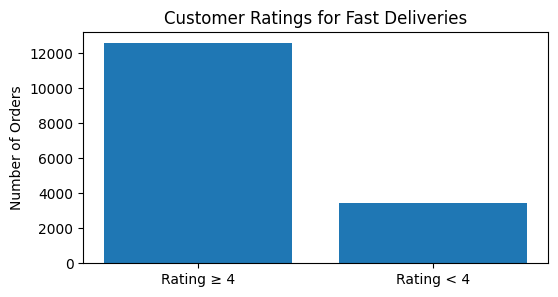

In [67]:
categories = [
    "Rating ≥ 4",
    "Rating < 4"
]

counts = [
    len(fast_high_rating),
    len(fast_orders) - len(fast_high_rating)
]

plt.figure(figsize=(6,3))
plt.bar(categories, counts)
plt.title("Customer Ratings for Fast Deliveries")
plt.ylabel("Number of Orders")
plt.show()

### Interpretation

- Given a Fast delivery, there is a 78.56% probability that the customer provides a rating of 4 or above, indicating that quicker deliveries are strongly associated with higher customer satisfaction.
- The high conditional probability suggests that delivery speed is a key operational factor influencing the customer experience and can positively impact satisfaction levels.
- However, approximately 21.44% of Fast deliveries still receive ratings below 4, indicating that delivery speed alone is not sufficient to ensure customer satisfaction. Other factors, such as food quality, order accuracy, packaging, and service experience, also play an important role.

### Business Recommendation

- Continue improving delivery efficiency to increase the proportion of Fast deliveries while simultaneously focusing on food quality, packaging, and order accuracy to further enhance customer satisfaction.
- Monitor customer feedback for Fast deliveries with low ratings to identify recurring service issues beyond delivery speed.

In [68]:
# Population Mean

population_mean = foodtech["Order_Value"].mean()
print(f"Population Mean Order Value : {population_mean:.2f}")

Population Mean Order Value : 545.68


In [69]:
# Random Samples

sample_30 = foodtech["Order_Value"].sample(n=30, random_state=42)
sample_50 = foodtech["Order_Value"].sample(n=50, random_state=42)
sample_100 = foodtech["Order_Value"].sample(n=100, random_state=42)

In [70]:
# Compare Means

print("Population Mean :", round(population_mean,2))
print("Sample Mean (30) :", round(sample_30.mean(),2))
print("Sample Mean (50) :", round(sample_50.mean(),2))
print("Sample Mean (100) :", round(sample_100.mean(),2))

Population Mean : 545.68
Sample Mean (30) : 537.33
Sample Mean (50) : 541.42
Sample Mean (100) : 546.85


In [71]:
# Create Comparison Table

comparison = pd.DataFrame({
    "Sample Size":[30,50,100],
    "Sample Mean":[
        sample_30.mean(),
        sample_50.mean(),
        sample_100.mean()
    ]
})

comparison

,Sample Size,Sample Mean
0,30,537.333333
1,50,541.420000
2,100,546.850000


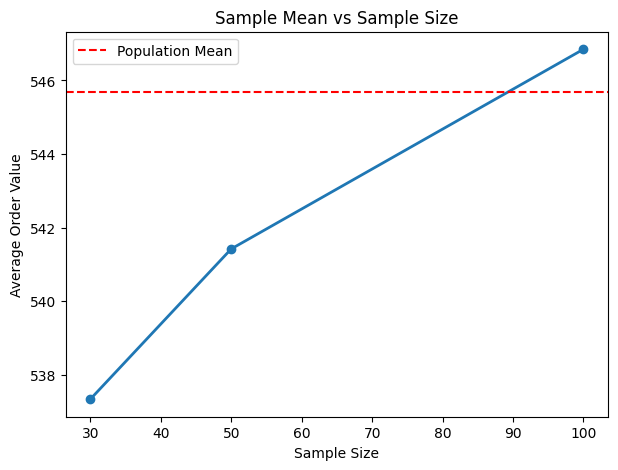

In [72]:
# Visualization

plt.figure(figsize=(7,5))

plt.plot(
    comparison["Sample Size"],
    comparison["Sample Mean"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=population_mean,
    color="red",
    linestyle="--",
    label="Population Mean"
)

plt.title("Sample Mean vs Sample Size")
plt.xlabel("Sample Size")
plt.ylabel("Average Order Value")
plt.legend()
plt.show()

### Interpretation

- As the sample size increased from 30 to 100, the sample mean moved closer to the population mean (₹545.68). The sample of 100 (₹546.85) provided a more accurate estimate than the sample of 30 (₹537.33), demonstrating the Law of Large Numbers.
- Smaller samples showed greater deviation from the population mean, indicating that business decisions based on limited data are more likely to misrepresent actual customer spending behavior.
- The results suggest that larger sample sizes (100 or more) should be preferred for estimating key business metrics, such as average order value, as they provide more reliable and consistent insights for decision-making.

### Business Recommendation

- Use larger random samples when evaluating customer spending patterns, campaign performance, or regional sales to improve the accuracy of business insights.
- Avoid relying on very small samples for strategic decisions, as they may overestimate or underestimate the true performance of the business.

In [73]:
# Population Mean

population_mean = foodtech["Order_Value"].mean()
print(f"Population Mean : {population_mean:.2f}")

Population Mean : 545.68


In [75]:
# Generate 1000 samples

sample_size = 30

num_samples = 1000

sample_means = []

for i in range(num_samples):

    sample = foodtech["Order_Value"].sample(
        n=sample_size,
        replace=True
    )

    sample_means.append(sample.mean())

# Verify
print("Number of Sample Means :", len(sample_means))
print("Average of Sample Means :", round(np.mean(sample_means),2))
print("Population Mean :", round(population_mean,2))

Number of Sample Means : 1000
Average of Sample Means : 545.28
Population Mean : 545.68


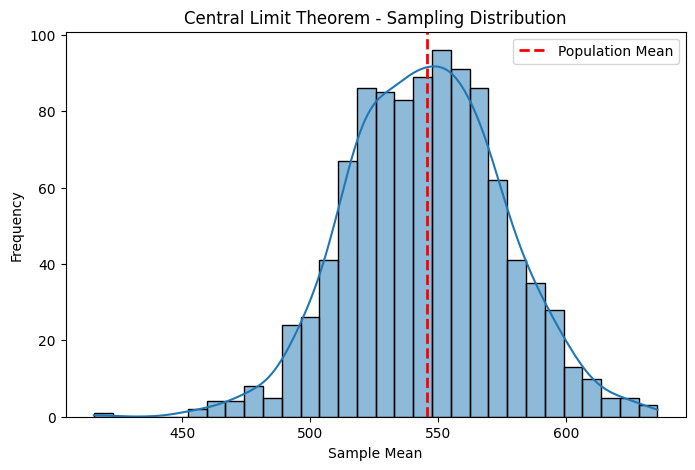

In [81]:
# Visualization
import seaborn as sns
plt.figure(figsize=(8,5))

sns.histplot(
    sample_means,
    bins=30,
    kde=True
)

plt.axvline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.title("Central Limit Theorem - Sampling Distribution")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Interpretation

- The distribution of the 1,000 sample means (each with a sample size of 30) forms an approximately bell-shaped normal distribution centered near the population mean (₹545.68), demonstrating the Central Limit Theorem. This occurs even though the distribution of individual order values may not be normally distributed.
- The average of the 1,000 sample means (₹545.28) is extremely close to the population mean (₹545.68), confirming that the sample mean is an unbiased estimator of the population mean.
- These findings demonstrate that random sampling with a moderate sample size (n = 30) provides reliable estimates of the average order value, making statistical analysis both accurate and practical for business decision-making.

### Business Recommendation

- Business teams can confidently use sample-based analysis instead of processing the entire 100,000-order dataset for routine reporting, customer behavior analysis, and campaign evaluation, reducing analysis time while maintaining reliable estimates.
- The Central Limit Theorem supports the use of statistical inference techniques, such as confidence intervals and hypothesis testing, enabling faster and more efficient data-driven decision-making.

In [ ]:
# Null Hypothesis (H₀) - There is no significant difference in the average delivery time between Urban and Metropolitan regions.

# Alternative Hypothesis (H₁) - There is a significant difference in the average delivery time between Urban and Metropolitan regions.

In [95]:
# Import Library

from statsmodels.stats.weightstats import ztest

In [91]:
# Extract Samples

urban = foodtech[
    foodtech["Region"]=="Urban"
]["Delivery_Time_Minutes"]

metro = foodtech[
    foodtech["Region"]=="Metropolitian"
]["Delivery_Time_Minutes"]

In [92]:
# Statistics

print("Urban Mean :", round(urban.mean(),2))
print("Metropolitan Mean :", round(metro.mean(),2))
print("Urban Sample Size :", len(urban))
print("Metropolitan Sample Size :", len(metro))

Urban Mean : 35.51
Metropolitan Mean : 35.5
Urban Sample Size : 33421
Metropolitan Sample Size : 33230


In [93]:
# Perform Z-Test

z_stat, p_value = ztest(
    urban,
    metro,
    value=0
)

print("Z Statistic :", round(z_stat,4))
print("P Value :", round(p_value,4))

Z Statistic : 0.2156
P Value : 0.8293


In [94]:
# Decision

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


### Interpretation

- The average delivery time in Urban (35.51 minutes) and Metropolitan (35.50 minutes) regions is nearly identical, with a difference of only 0.01 minutes.
- The p-value (0.8293) is greater than the significance level of 0.05, indicating that the observed difference in average delivery time is not statistically significant.
- Therefore, we fail to reject the null hypothesis, suggesting that delivery performance is consistent across Urban and Metropolitan regions, with no evidence of a meaningful difference in average delivery time.

### Business Recommendation

- Maintain the current logistics strategy across both Urban and Metropolitan regions, as delivery performance appears to be consistently managed.
- Focus operational improvements on other factors, such as reducing delayed deliveries, improving delivery efficiency, and enhancing customer satisfaction, rather than differentiating strategies solely based on these two regions.

In [ ]:
# Null Hypothesis (H₀): There is no significant association between Customer Type and Delivery Time Category.

# Alternative Hypothesis (H₁): There is a significant association between Customer Type and Delivery Time Category.

In [96]:
# Import library

from scipy.stats import chi2_contingency

In [97]:
# Create Contingency Table

contingency_table = pd.crosstab(
    foodtech["Customer_Type"],
    foodtech["Delivery_Time_Category"]
)

contingency_table

Delivery_Time_Category,Fast,Moderate,Slow
Customer_Type,,,
Loyal,1742,9087,231
New,8624,44192,1251
Returning,5631,28482,760


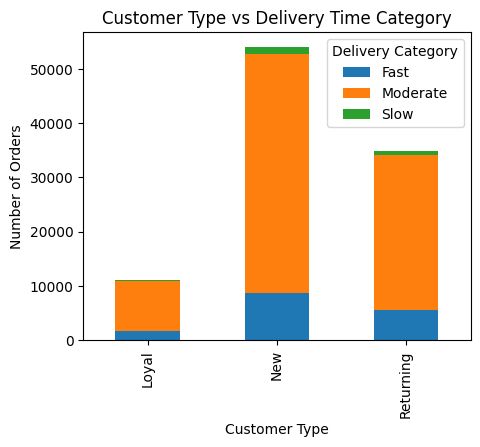

In [99]:
# Visualization

contingency_table.plot(
    kind="bar",
    stacked=True,
    figsize=(5,4)
)

plt.title("Customer Type vs Delivery Time Category")
plt.xlabel("Customer Type")
plt.ylabel("Number of Orders")
plt.legend(title="Delivery Category")
plt.show()

In [100]:
# Perform Chi-Square Test

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", round(chi2,4))
print("P Value :", round(p,4))
print("Degrees of Freedom :", dof)

Chi-Square Statistic : 4.2525
P Value : 0.3729
Degrees of Freedom : 4


In [101]:
# Decision

alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


### Interpretation

- The Chi-Square test produced a p-value of 0.3729, which is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis.
- This indicates that there is no statistically significant association between Customer Type (New, Returning, Loyal) and Delivery Time Category (Fast, Moderate, Slow). Delivery performance appears to be distributed similarly across all customer segments.
- The findings suggest that the logistics system provides a consistent delivery experience regardless of customer type, indicating that no specific customer segment is receiving preferential or inferior delivery performance.

### Business Recommendation

- Continue maintaining consistent delivery operations across all customer segments to ensure a fair and reliable customer experience.
- Rather than differentiating logistics strategies based on customer type, focus improvement efforts on operational factors such as route optimization, restaurant preparation time, and delivery partner performance to enhance overall service quality.

### Machine Learning

In [41]:
# Import required libraries
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [11]:
# Define x and y
X = foodtech[["Avg_Delivery_Speed_KMPH"]]
y = foodtech["Delivery_Efficiency_Score"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Build Model
model = LinearRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model Equation
print("Intercept :", model.intercept_)
print("Coefficient :", model.coef_[0])

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

Intercept : 0.2529837655845857
Coefficient : 0.021063019793601027
MAE : 0.13
MSE : 0.02
RMSE : 0.16
R² Score : 0.4358


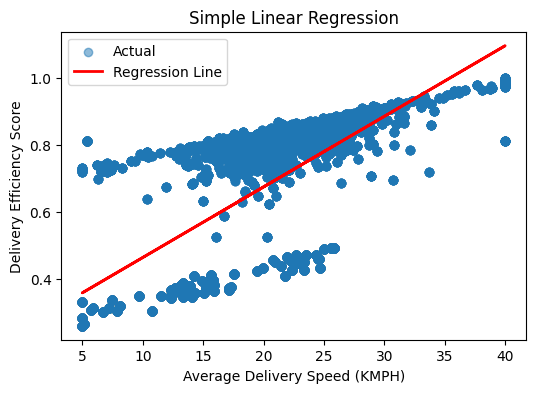

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual"
)

plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Delivery Speed (KMPH)")
plt.ylabel("Delivery Efficiency Score")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Interpretation

- Delivery speed has a positive relationship with delivery efficiency, with efficiency increasing by approximately 0.021 for every 1 km/h increase in speed.

- However, the R² of 0.4358 means speed alone explains only ~44% of the variation in delivery efficiency — the remaining ~56% is driven by other factors not captured here (likely vehicle type, preparation time, region, or traffic conditions, as seen in the earlier correlation matrix where Avg_Preparation_Time_Minutes had an even stronger -0.82 correlation with efficiency).

- The model is useful for identifying overall trends but is not sufficiently accurate for individual delivery predictions.

# Business Recommendation

- Improve delivery efficiency by optimizing delivery speed while also considering other key factors such as preparation time and vehicle type.
- Develop a Multiple Linear Regression model using additional operational variables to achieve more accurate predictions and better logistics planning.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
# Independent Variables (Operational Factors)

X = foodtech_analysis[
[
    "Avg_Delivery_Speed_KMPH",
    "Avg_Preparation_Time_Minutes",
    "Order_Capacity_Per_Day",
    "Festival_Flag"
]]

# Target Variable

y = foodtech_analysis["Delivery_Efficiency_Score"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [47]:
# Build model

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
# Predict

y_pred = model.predict(X_test)

In [50]:
# Coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients

,Feature,Coefficient
0,Avg_Delivery_Speed_KMPH,0.011311
1,Avg_Preparation_Time_Minutes,-0.016776
2,Order_Capacity_Per_Day,0.000532
3,Festival_Flag,0.000350


In [51]:
# Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))
print("R² Score :", round(r2,4))

MAE : 0.0684
RMSE : 0.0946
R² Score : 0.7926


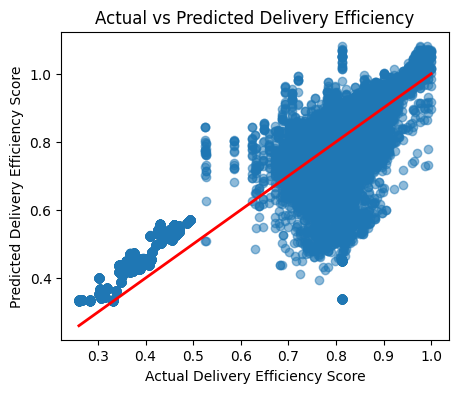

In [52]:
plt.figure(figsize=(5,4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Delivery Efficiency")
plt.xlabel("Actual Delivery Efficiency Score")
plt.ylabel("Predicted Delivery Efficiency Score")
plt.show()

### Business Insights

- The Multiple Linear Regression model significantly improved prediction performance, with the R² score increasing from 0.4358 to 0.7926, indicating that the selected operational factors explain approximately 79% of the variation in Delivery Efficiency Score.
- Average Preparation Time has the strongest negative influence on delivery efficiency, indicating that longer restaurant preparation times reduce overall operational performance more than delivery speed alone.
- The model achieved a lower prediction error (MAE = 0.0684) compared to the Simple Linear Regression model, making it more reliable for estimating delivery efficiency and supporting operational decision-making.

### Business Recommendation

- Prioritize reducing restaurant preparation time through better kitchen planning, staffing, and order management, as it has the greatest impact on delivery efficiency.
- Use this model to monitor delivery performance and identify orders at risk of lower efficiency, while considering additional variables such as Vehicle Type in future models to further improve prediction accuracy.

In [53]:
# Calculate residuals

residuals = y_test - y_pred
residuals.head()

75721   -0.027902
80184   -0.058584
19864   -0.057712
76699   -0.077764
92991   -0.088375
Name: Delivery_Efficiency_Score, dtype: float64

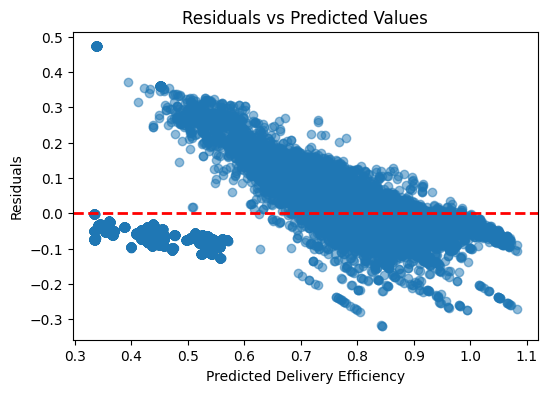

In [54]:
# Residual vs Predicted plot

plt.figure(figsize=(6,4))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Delivery Efficiency")
plt.ylabel("Residuals")
plt.show()

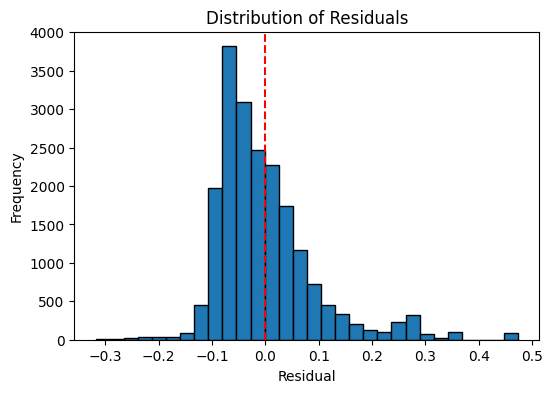

In [55]:
# Distribution of Residuals
plt.figure(figsize=(6,4))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [56]:
# Residual Mean 
print("Mean Residual :", round(residuals.mean(),6))

# Residual Standard Deviation
print("Residual Standard Deviation :", round(residuals.std(),4))

Mean Residual : -0.001746
Residual Standard Deviation : 0.0946


### Interpretation

- The residuals show a noticeable pattern instead of a completely random distribution, indicating that the current regression model does not fully capture all factors affecting delivery efficiency.
- Although the mean residual is close to zero (-0.0017), suggesting the model is unbiased overall, some orders are consistently over- or under-predicted.
- The residual distribution is approximately bell-shaped and centered around zero, but the presence of clustered errors suggests that additional operational variables could further improve model performance.

### Business Recommendation

- The model provides reliable overall predictions (R² = 0.7926) and can support operational planning, but it should be refined before being used for high-impact automated decisions.
- Include additional operational features such as Vehicle Type in future models to improve prediction accuracy and reduce systematic prediction errors.

In [64]:
# Convert Boolean to Integer
# A regression model and the variance_inflation_factor() function perform 
# mathematical calculations(matrix operations, regression equations, etc.). 
# These calculations require numeric values, not logical values.
# So I converted False, True to 0,1

foodtech_analysis["Festival_Flag"] = foodtech_analysis["Festival_Flag"].astype(int)

In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select Independent Variable
X = foodtech_analysis[
[
    "Avg_Delivery_Speed_KMPH",
    "Avg_Preparation_Time_Minutes",
    "Order_Capacity_Per_Day",
    "Festival_Flag"
]]

# Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif

,Variable,VIF
0,Avg_Delivery_Speed_KMPH,5.742738
1,Avg_Preparation_Time_Minutes,5.235581
2,Order_Capacity_Per_Day,1.448253
3,Festival_Flag,2.096448


# Interpretation

- Order Capacity Per Day (1.45) and Festival Flag (2.10) have low VIF values, indicating very little multicollinearity and that they contribute unique information to the regression model.
- Average Delivery Speed (5.74) and Average Preparation Time (5.24) show moderate multicollinearity, suggesting some overlap in the information they provide. However, their VIF values are well below the critical threshold of 10, so they can still be retained in the model.
- Overall, the predictor variables do not exhibit severe multicollinearity, indicating that the regression coefficients remain reasonably stable and the Multiple Linear Regression model is suitable for analysis.

# Business Recommendation

- The selected operational variables can be used together for predicting Delivery Efficiency Score, as multicollinearity is within an acceptable range and does not significantly affect model reliability.
- Future model improvements should focus on incorporating additional business-relevant operational variables rather than removing the current predictors, since no variable shows severe multicollinearity.

In [65]:
# Import libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# Create Binary Target Variable

foodtech_analysis["High_Efficiency"] = np.where(
    foodtech_analysis["Delivery_Efficiency_Score"] >= 0.70,
    1,
    0
)

foodtech_analysis["High_Efficiency"].value_counts()

High_Efficiency
1    67391
0    32609
Name: count, dtype: int64

In [77]:
# Select features

X = foodtech_analysis[
[
    "Avg_Delivery_Speed_KMPH",
    "Avg_Preparation_Time_Minutes",
    "Order_Capacity_Per_Day",
    "Festival_Flag"
]]

y = foodtech_analysis["High_Efficiency"]

In [78]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Accuracy : 93.96 %
[[ 6262   323]
 [  885 12530]]


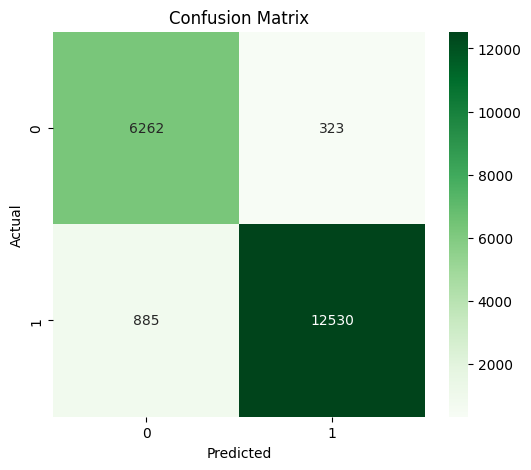

In [79]:
# Build Logistic Regression Model

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", round(accuracy*100,2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [80]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      6585
           1       0.97      0.93      0.95     13415

    accuracy                           0.94     20000
   macro avg       0.93      0.94      0.93     20000
weighted avg       0.94      0.94      0.94     20000



In [81]:
# Feature importance

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]

})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,Avg_Delivery_Speed_KMPH,0.152433
3,Festival_Flag,0.015455
2,Order_Capacity_Per_Day,0.002928
1,Avg_Preparation_Time_Minutes,-0.355569


# Interpretation

- The Logistic Regression model achieved an accuracy of 93.96%, indicating excellent performance in predicting whether a delivery will achieve a high delivery efficiency score.
- The model correctly identified most high-efficiency deliveries (Recall = 93%) while maintaining high prediction reliability (Precision = 97%), demonstrating strong classification performance across both classes.
- Average Preparation Time has the largest negative coefficient (-0.3556), making it the strongest factor reducing delivery efficiency. In contrast, Average Delivery Speed (0.1524) positively influences delivery efficiency, while Order Capacity Per Day and Festival Flag have only a minimal impact.

# Business Recommendation

- Reducing restaurant preparation time should be the primary operational focus, as it has the greatest influence on achieving high delivery efficiency. Improving kitchen workflows and reducing preparation delays can significantly enhance delivery performance.
- Maintaining higher delivery speeds through efficient routing and vehicle allocation can further improve delivery efficiency, while restaurant capacity and festival periods require comparatively less operational attention.

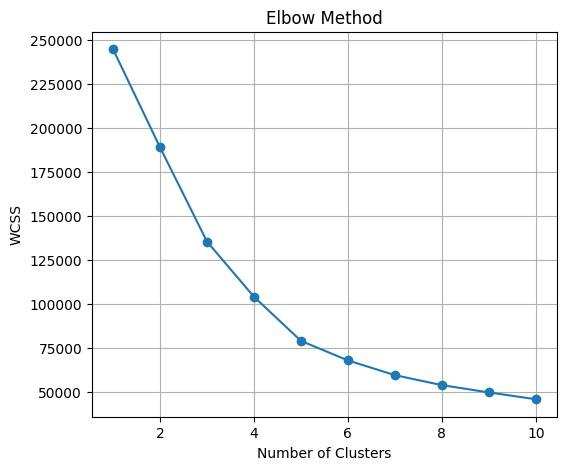

In [83]:
# Import libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features
restaurant_cluster = foodtech_analysis[
[
    "Restaurant_ID",
    "Avg_Preparation_Time_Minutes",
    "Avg_Delivery_Speed_KMPH",
    "Avg_Rating",
    "Order_Capacity_Per_Day"
]
].drop_duplicates()
restaurant_cluster.head()

# Scale the data
features = restaurant_cluster[
[
    "Avg_Preparation_Time_Minutes",
    "Avg_Delivery_Speed_KMPH",
    "Avg_Rating",
    "Order_Capacity_Per_Day"
]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow method
wcss = []
for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    wcss.append(model.inertia_)

# Plot Elbow curve
plt.figure(figsize=(6,5))
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [84]:
# Build K-Means Model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

restaurant_cluster["Cluster"] = kmeans.fit_predict(scaled_features)
restaurant_cluster.head()

,Restaurant_ID,Avg_Preparation_Time_Minutes,Avg_Delivery_Speed_KMPH,Avg_Rating,Order_Capacity_Per_Day,Cluster
0,R282,27,18.508503,4.60,103,2
1,R181,40,6.732085,4.00,1,4
2,R303,40,12.305082,4.50,1,1
3,R409,40,25.795431,4.40,1,1
4,R358,40,19.445410,4.75,2,1


In [85]:
# Cluster summary
cluster_summary = restaurant_cluster.groupby("Cluster")[
[
    "Avg_Preparation_Time_Minutes",
    "Avg_Delivery_Speed_KMPH",
    "Avg_Rating",
    "Order_Capacity_Per_Day"
]
].mean().round(2)

cluster_summary

,Avg_Preparation_Time_Minutes,Avg_Delivery_Speed_KMPH,Avg_Rating,Order_Capacity_Per_Day
Cluster,,,,
0,23.89,18.96,4.67,17.73
1,37.17,19.76,4.63,2.92
2,27.25,21.98,4.62,118.05
3,23.78,27.04,4.67,17.90
4,34.25,19.92,3.73,1.10


In [86]:
cluster_size = restaurant_cluster["Cluster"].value_counts().sort_index()
print(cluster_size)

Cluster
0    22687
1     6957
2     9960
3    19842
4     1703
Name: count, dtype: int64


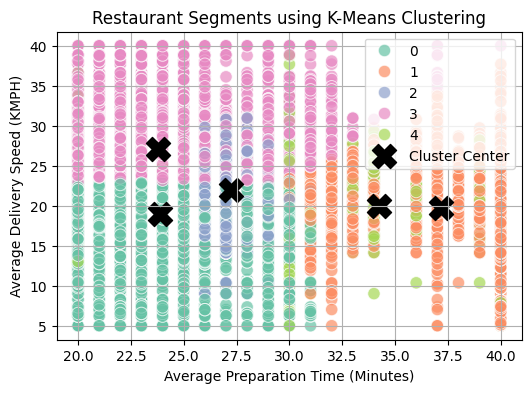

In [91]:
# Cluster Visualization
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=restaurant_cluster,
    x="Avg_Preparation_Time_Minutes",
    y="Avg_Delivery_Speed_KMPH",
    hue="Cluster",
    palette="Set2",
    s=80,
    alpha=0.7
)

# Plot cluster centers
plt.scatter(
    centers["Avg_Preparation_Time_Minutes"],
    centers["Avg_Delivery_Speed_KMPH"],
    c="black",
    s=300,
    marker="X",
    label="Cluster Center"
)

plt.title("Restaurant Segments using K-Means Clustering")
plt.xlabel("Average Preparation Time (Minutes)")
plt.ylabel("Average Delivery Speed (KMPH)")
plt.legend()
plt.grid(True)
plt.show()

In [90]:
# Cluster Centers
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=[
        "Avg_Preparation_Time_Minutes",
        "Avg_Delivery_Speed_KMPH",
        "Avg_Rating",
        "Order_Capacity_Per_Day"
    ]
)
centers.round(2)

,Avg_Preparation_Time_Minutes,Avg_Delivery_Speed_KMPH,Avg_Rating,Order_Capacity_Per_Day
0,23.89,18.96,4.67,17.73
1,37.17,19.76,4.63,2.92
2,27.25,21.98,4.62,118.05
3,23.78,27.04,4.67,17.91
4,34.25,19.92,3.73,1.10


# Interpretation

- K-Means Clustering segmented restaurants into five distinct operational groups, revealing meaningful differences in preparation time, delivery speed, customer ratings, and daily order capacity.
- High Performance Restaurants (Cluster 3) achieve the fastest delivery speed (27.04 km/h) while maintaining excellent customer ratings (4.67), indicating efficient operations. In contrast, Low Performing Restaurants (Cluster 4) have the lowest customer rating (3.73), longer preparation times (34.25 minutes), and the smallest order capacity, highlighting operational weaknesses.
- High Capacity Restaurants (Cluster 2) handle the highest daily order volume (118 orders/day) while maintaining good delivery speed and customer ratings, demonstrating that high operational volume can be achieved without sacrificing service quality.

# Business Recommendation

- Use High Performance Restaurants (Cluster 3) as operational benchmarks by replicating their delivery practices, routing strategies, and kitchen workflows across other restaurant groups.
- Prioritize operational improvement programs for Slow Preparation Restaurants (Cluster 1) and Low Performing Restaurants (Cluster 4) by reducing preparation delays, improving staff efficiency, and monitoring service quality to enhance customer satisfaction.
- Study the practices of High Capacity Restaurants (Cluster 2) to identify scalable operational strategies that can help other restaurants increase order handling capacity while maintaining delivery performance.

Accuracy : 98.07 %
[[ 6295   290]
 [   96 13319]]


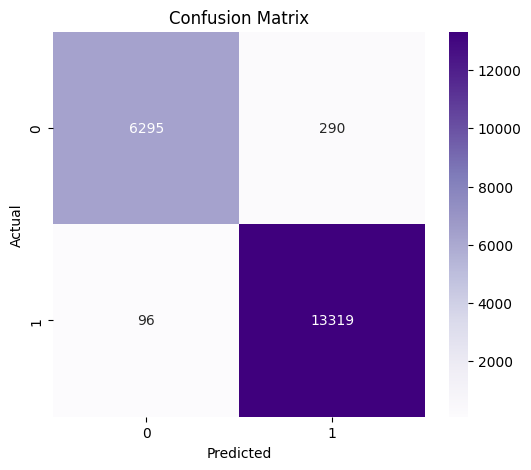

In [92]:
# Import libraries
from sklearn.neighbors import KNeighborsClassifier

# Features and Target
X = foodtech_analysis[
[
    "Avg_Delivery_Speed_KMPH",
    "Avg_Preparation_Time_Minutes",
    "Order_Capacity_Per_Day",
    "Festival_Flag"
]]
y = foodtech_analysis["High_Efficiency"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build KNN model
k = 5
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred = knn.predict(
    X_test_scaled
)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy :",
    round(accuracy*100,2),
    "%"
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [93]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      6585
           1       0.98      0.99      0.99     13415

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [95]:
# Since I already know the Logistic Regression accuracy is 93.96%
logistic_accuracy = 93.96

# Model Comparison
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy":[
        logistic_accuracy,
        accuracy
    ]
})
comparison

,Model,Accuracy
0,Logistic Regression,93.9600
1,KNN,0.9807


# Interpretation

- The K-Nearest Neighbors (KNN) model achieved an accuracy of 98.07%, outperforming the Logistic Regression model (93.96%), making it the best-performing predictive model in this project.
- The confusion matrix shows that the model correctly classified 13,319 high-efficiency deliveries and 6,295 low-efficiency deliveries, with very few misclassifications (only 386 out of 20,000 test observations), demonstrating excellent predictive capability.
- The model achieved 98% precision, 99% recall, and an F1-score of 99% for high-efficiency deliveries, indicating that KNN reliably distinguishes efficient and inefficient deliveries based on operational characteristics.

# Business Recommendation

- The KNN model can be used as a decision-support tool to identify deliveries that are likely to achieve high operational efficiency before dispatch, enabling proactive resource planning.
- Since KNN provides the highest prediction accuracy among all evaluated models, it should be preferred over Logistic Regression for operational efficiency prediction, helping FoodTech improve delivery planning and monitor service quality more effectively.